In [1]:
!pip -q install yfinance scipy seaborn

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Automated DCF Valuation Engine

### Python-based Fundamental Valuation Model

This project estimates a company's intrinsic equity value using discounted cash flow analysis.

In [3]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

TICKER = "AAPL"

FORECAST_YEARS = 5

TERMINAL_GROWTH_RATE = 0.025

RISK_FREE_RATE = 0.043
EQUITY_RISK_PREMIUM = 0.055

TAX_RATE = 0.21

REVENUE_GROWTH_RATE = 0.08
EBIT_MARGIN = 0.30
DA_PERCENT_REVENUE = 0.04
CAPEX_PERCENT_REVENUE = 0.04
NWC_PERCENT_REVENUE = 0.02

COST_OF_DEBT = 0.045

print(f"DCF Model initialized for {TICKER}")

DCF Model initialized for AAPL


In [4]:
# ============================================================
# DATA COLLECTION
# ============================================================

def load_company_data(ticker):

    try:
        stock = yf.Ticker(ticker)

        income_statement = stock.income_stmt
        balance_sheet = stock.balance_sheet
        cash_flow = stock.cashflow
        history = stock.history(period="5d")

        if history.empty:
            raise ValueError("No market-price data returned.")

        return {
            "stock": stock,
            "income_statement": income_statement,
            "balance_sheet": balance_sheet,
            "cash_flow": cash_flow,
            "history": history
        }

    except Exception as e:
        raise RuntimeError(
            f"Unable to retrieve data for {ticker}: {e}"
        )


data = load_company_data(TICKER)

print("Data successfully downloaded!")

Data successfully downloaded!


In [5]:
income_statement = data["income_statement"]
balance_sheet = data["balance_sheet"]
cash_flow = data["cash_flow"]

print("INCOME STATEMENT")
display(income_statement.head(15))

print("BALANCE SHEET")
display(balance_sheet.head(15))

print("CASH FLOW STATEMENT")
display(cash_flow.head(15))

INCOME STATEMENT


,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Tax Effect Of Unusual Items,0.00,0.00,0.00,0.00,NaN
Tax Rate For Calcs,0.16,0.24,0.15,0.16,NaN
Normalized EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
Net Income From Continuing Operation Net Minority Interest,"112,010,000,000.00","93,736,000,000.00","96,995,000,000.00","99,803,000,000.00",NaN
Reconciled Depreciation,"11,698,000,000.00","11,445,000,000.00","11,519,000,000.00","11,104,000,000.00",NaN
Reconciled Cost Of Revenue,"220,960,000,000.00","210,352,000,000.00","214,137,000,000.00","223,546,000,000.00",NaN
EBITDA,"144,748,000,000.00","134,661,000,000.00","125,820,000,000.00","130,541,000,000.00",NaN
EBIT,"133,050,000,000.00","123,216,000,000.00","114,301,000,000.00","119,437,000,000.00",NaN
Net Interest Income,NaN,NaN,"-183,000,000.00","-106,000,000.00","198,000,000.00"
Interest Expense,NaN,NaN,"3,933,000,000.00","2,931,000,000.00","2,645,000,000.00"


BALANCE SHEET


,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Treasury Shares Number,NaN,NaN,0.00,NaN,NaN
Ordinary Shares Number,"14,773,260,000.00","15,116,786,000.00","15,550,061,000.00","15,943,425,000.00",NaN
Share Issued,"14,773,260,000.00","15,116,786,000.00","15,550,061,000.00","15,943,425,000.00",NaN
Net Debt,"62,723,000,000.00","76,686,000,000.00","81,123,000,000.00","96,423,000,000.00",NaN
Total Debt,"98,657,000,000.00","106,629,000,000.00","111,088,000,000.00","132,480,000,000.00",NaN
Tangible Book Value,"73,733,000,000.00","56,950,000,000.00","62,146,000,000.00","50,672,000,000.00",NaN
Invested Capital,"172,390,000,000.00","163,579,000,000.00","173,234,000,000.00","170,741,000,000.00",NaN
Working Capital,"-17,674,000,000.00","-23,405,000,000.00","-1,742,000,000.00","-18,577,000,000.00",NaN
Net Tangible Assets,"73,733,000,000.00","56,950,000,000.00","62,146,000,000.00","50,672,000,000.00",NaN
Capital Lease Obligations,NaN,NaN,"12,842,000,000.00","12,411,000,000.00","11,803,000,000.00"


CASH FLOW STATEMENT


,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Free Cash Flow,"98,767,000,000.00","108,807,000,000.00","99,584,000,000.00","111,443,000,000.00",NaN
Repurchase Of Capital Stock,"-90,711,000,000.00","-94,949,000,000.00","-77,550,000,000.00","-89,402,000,000.00",NaN
Repayment Of Debt,"-10,932,000,000.00","-9,958,000,000.00","-11,151,000,000.00","-9,543,000,000.00",NaN
Issuance Of Debt,"4,481,000,000.00",0.00,"5,228,000,000.00","5,465,000,000.00",NaN
Issuance Of Capital Stock,NaN,NaN,NaN,NaN,"1,105,000,000.00"
Capital Expenditure,"-12,715,000,000.00","-9,447,000,000.00","-10,959,000,000.00","-10,708,000,000.00",NaN
Interest Paid Supplemental Data,NaN,NaN,"3,803,000,000.00","2,865,000,000.00","2,687,000,000.00"
Income Tax Paid Supplemental Data,"43,369,000,000.00","26,102,000,000.00","18,679,000,000.00","19,573,000,000.00",NaN
End Cash Position,"35,934,000,000.00","29,943,000,000.00","30,737,000,000.00","24,977,000,000.00",NaN
Beginning Cash Position,"29,943,000,000.00","30,737,000,000.00","24,977,000,000.00","35,929,000,000.00",NaN


In [6]:
# ============================================================
# FINANCIAL DATA HELPER
# ============================================================

def find_line_item(df, possible_names):
    """
    Finds a financial statement line item using exact
    or partial name matching.
    """

    if df is None or df.empty:
        return None

    # Try exact matches first
    for name in possible_names:
        if name in df.index:
            return df.loc[name]

    # Try partial matches
    for index_name in df.index:
        index_string = str(index_name).lower()

        for name in possible_names:
            if name.lower() in index_string:
                return df.loc[index_name]

    return None


print("Financial data helper ready!")

Financial data helper ready!


In [7]:
# ============================================================
# HISTORICAL REVENUE
# ============================================================

revenue = find_line_item(
    income_statement,
    [
        "Total Revenue",
        "Operating Revenue",
        "Revenue"
    ]
)

if revenue is None:
    raise ValueError("Revenue could not be found.")

revenue = revenue.dropna().sort_index()

print("Historical Revenue:")
display(revenue)

Historical Revenue:


,Total Revenue
2022-09-30,"394,328,000,000.00"
2023-09-30,"383,285,000,000.00"
2024-09-30,"391,035,000,000.00"
2025-09-30,"416,161,000,000.00"


In [8]:
# ============================================================
# REVENUE GROWTH
# ============================================================

revenue_growth = revenue.pct_change() * 100

revenue_analysis = pd.DataFrame({
    "Revenue": revenue,
    "YoY Growth (%)": revenue_growth
})

display(revenue_analysis)

,Revenue,YoY Growth (%)
2022-09-30,"394,328,000,000.00",NaN
2023-09-30,"383,285,000,000.00",-2.80
2024-09-30,"391,035,000,000.00",2.02
2025-09-30,"416,161,000,000.00",6.43


In [9]:
# ============================================================
# HISTORICAL EBIT
# ============================================================

ebit = find_line_item(
    income_statement,
    [
        "Operating Income",
        "EBIT"
    ]
)

if ebit is None:
    raise ValueError("EBIT could not be found.")

ebit = ebit.dropna().sort_index()

print("Historical EBIT:")
display(ebit)

Historical EBIT:


,Operating Income
2022-09-30,"119,437,000,000.00"
2023-09-30,"114,301,000,000.00"
2024-09-30,"123,216,000,000.00"
2025-09-30,"133,050,000,000.00"


In [10]:
# ============================================================
# EBIT MARGIN
# ============================================================

common_periods = revenue.index.intersection(ebit.index)

margin_analysis = pd.DataFrame({
    "Revenue": revenue.loc[common_periods],
    "EBIT": ebit.loc[common_periods]
})

margin_analysis["EBIT Margin (%)"] = (
    margin_analysis["EBIT"] /
    margin_analysis["Revenue"]
) * 100

display(margin_analysis)

,Revenue,EBIT,EBIT Margin (%)
2022-09-30,"394,328,000,000.00","119,437,000,000.00",30.29
2023-09-30,"383,285,000,000.00","114,301,000,000.00",29.82
2024-09-30,"391,035,000,000.00","123,216,000,000.00",31.51
2025-09-30,"416,161,000,000.00","133,050,000,000.00",31.97


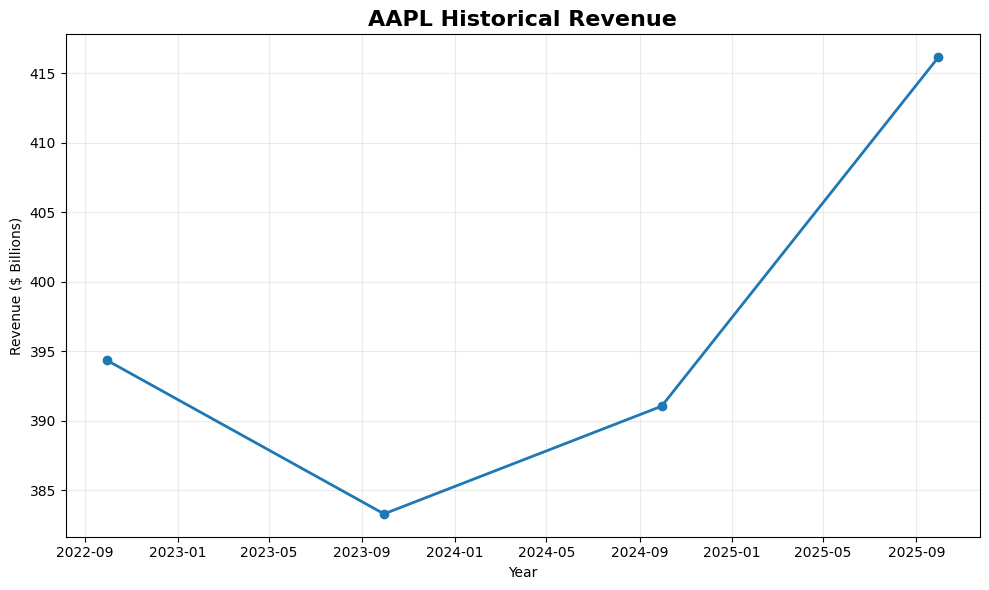

In [11]:
# ============================================================
# HISTORICAL REVENUE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    revenue.index,
    revenue.values / 1e9,
    marker="o",
    linewidth=2
)

plt.title(
    f"{TICKER} Historical Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Revenue ($ Billions)")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# HISTORICAL DEPRECIATION & AMORTIZATION
# ============================================================

da = find_line_item(
    cash_flow,
    [
        "Depreciation And Amortization",
        "Depreciation",
        "Depreciation And Amortization In Cash Flow Statement"
    ]
)

if da is None:
    raise ValueError(
        "Depreciation & Amortization data could not be found."
    )

da = da.dropna().sort_index().abs()

print("Historical D&A:")
display(da)

Historical D&A:


,Depreciation And Amortization
2022-09-30,"11,104,000,000.00"
2023-09-30,"11,519,000,000.00"
2024-09-30,"11,445,000,000.00"
2025-09-30,"11,698,000,000.00"


In [13]:
# ============================================================
# HISTORICAL CAPITAL EXPENDITURE
# ============================================================

capex = find_line_item(
    cash_flow,
    [
        "Capital Expenditure",
        "Capital Expenditure Reported",
        "Purchase Of PPE"
    ]
)

if capex is None:
    raise ValueError(
        "Capital expenditure data could not be found."
    )

capex = capex.dropna().sort_index().abs()

print("Historical Capital Expenditure:")
display(capex)

Historical Capital Expenditure:


,Capital Expenditure
2022-09-30,"10,708,000,000.00"
2023-09-30,"10,959,000,000.00"
2024-09-30,"9,447,000,000.00"
2025-09-30,"12,715,000,000.00"


In [14]:
# ============================================================
# HISTORICAL WORKING CAPITAL
# ============================================================

accounts_receivable = find_line_item(
    balance_sheet,
    [
        "Accounts Receivable",
        "Net Receivables"
    ]
)

inventory = find_line_item(
    balance_sheet,
    [
        "Inventory"
    ]
)

accounts_payable = find_line_item(
    balance_sheet,
    [
        "Accounts Payable"
    ]
)

if accounts_receivable is None:
    raise ValueError("Accounts Receivable not found.")

if inventory is None:
    raise ValueError("Inventory not found.")

if accounts_payable is None:
    raise ValueError("Accounts Payable not found.")


# Align the dates across all three datasets
common_dates = (
    accounts_receivable.index
    .intersection(inventory.index)
    .intersection(accounts_payable.index)
)

nwc = (
    accounts_receivable.loc[common_dates]
    + inventory.loc[common_dates]
    - accounts_payable.loc[common_dates]
)

nwc = nwc.sort_index()

print("Historical Net Working Capital:")
display(nwc)

Historical Net Working Capital:


,0
2021-09-30,NaN
2022-09-30,"-30,985,000,000.00"
2023-09-30,"-26,772,000,000.00"
2024-09-30,"-28,264,000,000.00"
2025-09-30,"-24,365,000,000.00"


In [15]:
# ============================================================
# HISTORICAL FINANCIAL SUMMARY
# ============================================================

common_dates = (
    revenue.index
    .intersection(ebit.index)
    .intersection(da.index)
    .intersection(capex.index)
    .intersection(nwc.index)
)

historical = pd.DataFrame({
    "Revenue": revenue.loc[common_dates],
    "EBIT": ebit.loc[common_dates],
    "D&A": da.loc[common_dates],
    "CapEx": capex.loc[common_dates],
    "NWC": nwc.loc[common_dates]
})

historical["EBIT Margin"] = (
    historical["EBIT"] /
    historical["Revenue"]
)

historical["D&A % Revenue"] = (
    historical["D&A"] /
    historical["Revenue"]
)

historical["CapEx % Revenue"] = (
    historical["CapEx"] /
    historical["Revenue"]
)

historical["NWC % Revenue"] = (
    historical["NWC"] /
    historical["Revenue"]
)

display(historical)

,Revenue,EBIT,D&A,CapEx,NWC,EBIT Margin,D&A % Revenue,CapEx % Revenue,NWC % Revenue
2022-09-30,"394,328,000,000.00","119,437,000,000.00","11,104,000,000.00","10,708,000,000.00","-30,985,000,000.00",0.30,0.03,0.03,-0.08
2023-09-30,"383,285,000,000.00","114,301,000,000.00","11,519,000,000.00","10,959,000,000.00","-26,772,000,000.00",0.30,0.03,0.03,-0.07
2024-09-30,"391,035,000,000.00","123,216,000,000.00","11,445,000,000.00","9,447,000,000.00","-28,264,000,000.00",0.32,0.03,0.02,-0.07
2025-09-30,"416,161,000,000.00","133,050,000,000.00","11,698,000,000.00","12,715,000,000.00","-24,365,000,000.00",0.32,0.03,0.03,-0.06


In [16]:
# ============================================================
# HISTORICAL FREE CASH FLOW
# ============================================================

historical["Tax Rate"] = TAX_RATE

historical["NOPAT"] = (
    historical["EBIT"] *
    (1 - historical["Tax Rate"])
)

historical["Change in NWC"] = (
    historical["NWC"].diff()
)

historical["FCF"] = (
    historical["NOPAT"]
    + historical["D&A"]
    - historical["CapEx"]
    - historical["Change in NWC"]
)

display(
    historical[
        [
            "Revenue",
            "EBIT",
            "NOPAT",
            "D&A",
            "CapEx",
            "Change in NWC",
            "FCF"
        ]
    ]
)

,Revenue,EBIT,NOPAT,D&A,CapEx,Change in NWC,FCF
2022-09-30,"394,328,000,000.00","119,437,000,000.00","94,355,230,000.00","11,104,000,000.00","10,708,000,000.00",NaN,NaN
2023-09-30,"383,285,000,000.00","114,301,000,000.00","90,297,790,000.00","11,519,000,000.00","10,959,000,000.00","4,213,000,000.00","86,644,790,000.00"
2024-09-30,"391,035,000,000.00","123,216,000,000.00","97,340,640,000.00","11,445,000,000.00","9,447,000,000.00","-1,492,000,000.00","100,830,640,000.00"
2025-09-30,"416,161,000,000.00","133,050,000,000.00","105,109,500,000.00","11,698,000,000.00","12,715,000,000.00","3,899,000,000.00","100,193,500,000.00"


In [17]:
# ============================================================
# HISTORICAL FORECASTING METRICS
# ============================================================

# Calculate historical revenue growth
historical["Revenue Growth"] = (
    historical["Revenue"].pct_change()
)

# Calculate historical EBIT margin
historical["EBIT Margin"] = (
    historical["EBIT"] /
    historical["Revenue"]
)

# Calculate D&A as % of revenue
historical["D&A % Revenue"] = (
    historical["D&A"] /
    historical["Revenue"]
)

# Calculate CapEx as % of revenue
historical["CapEx % Revenue"] = (
    historical["CapEx"] /
    historical["Revenue"]
)

# Calculate NWC as % of revenue
historical["NWC % Revenue"] = (
    historical["NWC"] /
    historical["Revenue"]
)

display(
    historical[
        [
            "Revenue",
            "Revenue Growth",
            "EBIT Margin",
            "D&A % Revenue",
            "CapEx % Revenue",
            "NWC % Revenue"
        ]
    ]
)

,Revenue,Revenue Growth,EBIT Margin,D&A % Revenue,CapEx % Revenue,NWC % Revenue
2022-09-30,"394,328,000,000.00",NaN,0.30,0.03,0.03,-0.08
2023-09-30,"383,285,000,000.00",-0.03,0.30,0.03,0.03,-0.07
2024-09-30,"391,035,000,000.00",0.02,0.32,0.03,0.02,-0.07
2025-09-30,"416,161,000,000.00",0.06,0.32,0.03,0.03,-0.06


In [18]:
# ============================================================
# FORECAST ASSUMPTIONS
# ============================================================

forecast_assumptions = {
    "Revenue Growth": REVENUE_GROWTH_RATE,
    "EBIT Margin": EBIT_MARGIN,
    "D&A % Revenue": DA_PERCENT_REVENUE,
    "CapEx % Revenue": CAPEX_PERCENT_REVENUE,
    "NWC % Revenue": NWC_PERCENT_REVENUE,
    "Tax Rate": TAX_RATE
}

assumptions_df = pd.DataFrame({
    "Assumption": forecast_assumptions.keys(),
    "Value": [
        f"{value:.2%}"
        for value in forecast_assumptions.values()
    ]
})

display(assumptions_df)

,Assumption,Value
0,Revenue Growth,8.00%
1,EBIT Margin,30.00%
2,D&A % Revenue,4.00%
3,CapEx % Revenue,4.00%
4,NWC % Revenue,2.00%
5,Tax Rate,21.00%


In [19]:
# ============================================================
# REVENUE FORECAST
# ============================================================

latest_revenue = historical["Revenue"].iloc[-1]

forecast_years = [
    f"Year {i}"
    for i in range(1, FORECAST_YEARS + 1)
]

forecast_revenue = []

previous_revenue = latest_revenue

for year in range(FORECAST_YEARS):

    next_revenue = (
        previous_revenue *
        (1 + REVENUE_GROWTH_RATE)
    )

    forecast_revenue.append(next_revenue)

    previous_revenue = next_revenue

forecast_revenue = pd.Series(
    forecast_revenue,
    index=forecast_years
)

print("Forecast Revenue:")
display(
    pd.DataFrame({
        "Revenue": forecast_revenue
    })
)

Forecast Revenue:


,Revenue
Year 1,"449,453,880,000.00"
Year 2,"485,410,190,400.00"
Year 3,"524,243,005,632.00"
Year 4,"566,182,446,082.56"
Year 5,"611,477,041,769.17"


In [20]:
# ============================================================
# EBIT FORECAST
# ============================================================

forecast_ebit = (
    forecast_revenue *
    EBIT_MARGIN
)

print("Forecast EBIT:")
display(
    pd.DataFrame({
        "Revenue": forecast_revenue,
        "EBIT": forecast_ebit,
        "EBIT Margin": EBIT_MARGIN
    })
)

Forecast EBIT:


,Revenue,EBIT,EBIT Margin
Year 1,"449,453,880,000.00","134,836,164,000.00",0.30
Year 2,"485,410,190,400.00","145,623,057,120.00",0.30
Year 3,"524,243,005,632.00","157,272,901,689.60",0.30
Year 4,"566,182,446,082.56","169,854,733,824.77",0.30
Year 5,"611,477,041,769.17","183,443,112,530.75",0.30


In [21]:
# ============================================================
# NOPAT FORECAST
# ============================================================

forecast_taxes = (
    forecast_ebit *
    TAX_RATE
)

forecast_nopat = (
    forecast_ebit -
    forecast_taxes
)

print("Forecast NOPAT:")
display(
    pd.DataFrame({
        "EBIT": forecast_ebit,
        "Taxes": forecast_taxes,
        "NOPAT": forecast_nopat
    })
)

Forecast NOPAT:


,EBIT,Taxes,NOPAT
Year 1,"134,836,164,000.00","28,315,594,440.00","106,520,569,560.00"
Year 2,"145,623,057,120.00","30,580,841,995.20","115,042,215,124.80"
Year 3,"157,272,901,689.60","33,027,309,354.82","124,245,592,334.78"
Year 4,"169,854,733,824.77","35,669,494,103.20","134,185,239,721.57"
Year 5,"183,443,112,530.75","38,523,053,631.46","144,920,058,899.29"


In [22]:
# ============================================================
# D&A FORECAST
# ============================================================

forecast_da = (
    forecast_revenue *
    DA_PERCENT_REVENUE
)

display(
    pd.DataFrame({
        "Revenue": forecast_revenue,
        "D&A": forecast_da
    })
)

,Revenue,D&A
Year 1,"449,453,880,000.00","17,978,155,200.00"
Year 2,"485,410,190,400.00","19,416,407,616.00"
Year 3,"524,243,005,632.00","20,969,720,225.28"
Year 4,"566,182,446,082.56","22,647,297,843.30"
Year 5,"611,477,041,769.17","24,459,081,670.77"


In [23]:
# ============================================================
# CAPEX FORECAST
# ============================================================

forecast_capex = (
    forecast_revenue *
    CAPEX_PERCENT_REVENUE
)

display(
    pd.DataFrame({
        "Revenue": forecast_revenue,
        "CapEx": forecast_capex
    })
)

,Revenue,CapEx
Year 1,"449,453,880,000.00","17,978,155,200.00"
Year 2,"485,410,190,400.00","19,416,407,616.00"
Year 3,"524,243,005,632.00","20,969,720,225.28"
Year 4,"566,182,446,082.56","22,647,297,843.30"
Year 5,"611,477,041,769.17","24,459,081,670.77"


In [24]:
# ============================================================
# WORKING CAPITAL FORECAST
# ============================================================

forecast_nwc = (
    forecast_revenue *
    NWC_PERCENT_REVENUE
)

previous_nwc = (
    latest_revenue *
    NWC_PERCENT_REVENUE
)

delta_nwc = []

for current_nwc in forecast_nwc:

    change = current_nwc - previous_nwc

    delta_nwc.append(change)

    previous_nwc = current_nwc

delta_nwc = pd.Series(
    delta_nwc,
    index=forecast_years
)

display(
    pd.DataFrame({
        "NWC": forecast_nwc,
        "Change in NWC": delta_nwc
    })
)

,NWC,Change in NWC
Year 1,"8,989,077,600.00","665,857,600.00"
Year 2,"9,708,203,808.00","719,126,208.00"
Year 3,"10,484,860,112.64","776,656,304.64"
Year 4,"11,323,648,921.65","838,788,809.01"
Year 5,"12,229,540,835.38","905,891,913.73"


In [25]:
# ============================================================
# FORECAST FREE CASH FLOW
# ============================================================

forecast_fcf = (
    forecast_nopat
    + forecast_da
    - forecast_capex
    - delta_nwc
)

forecast_df = pd.DataFrame({
    "Revenue": forecast_revenue,
    "EBIT": forecast_ebit,
    "NOPAT": forecast_nopat,
    "D&A": forecast_da,
    "CapEx": forecast_capex,
    "Change in NWC": delta_nwc,
    "FCF": forecast_fcf
})

display(forecast_df)

,Revenue,EBIT,NOPAT,D&A,CapEx,Change in NWC,FCF
Year 1,"449,453,880,000.00","134,836,164,000.00","106,520,569,560.00","17,978,155,200.00","17,978,155,200.00","665,857,600.00","105,854,711,960.00"
Year 2,"485,410,190,400.00","145,623,057,120.00","115,042,215,124.80","19,416,407,616.00","19,416,407,616.00","719,126,208.00","114,323,088,916.80"
Year 3,"524,243,005,632.00","157,272,901,689.60","124,245,592,334.78","20,969,720,225.28","20,969,720,225.28","776,656,304.64","123,468,936,030.14"
Year 4,"566,182,446,082.56","169,854,733,824.77","134,185,239,721.57","22,647,297,843.30","22,647,297,843.30","838,788,809.01","133,346,450,912.56"
Year 5,"611,477,041,769.17","183,443,112,530.75","144,920,058,899.29","24,459,081,670.77","24,459,081,670.77","905,891,913.73","144,014,166,985.56"


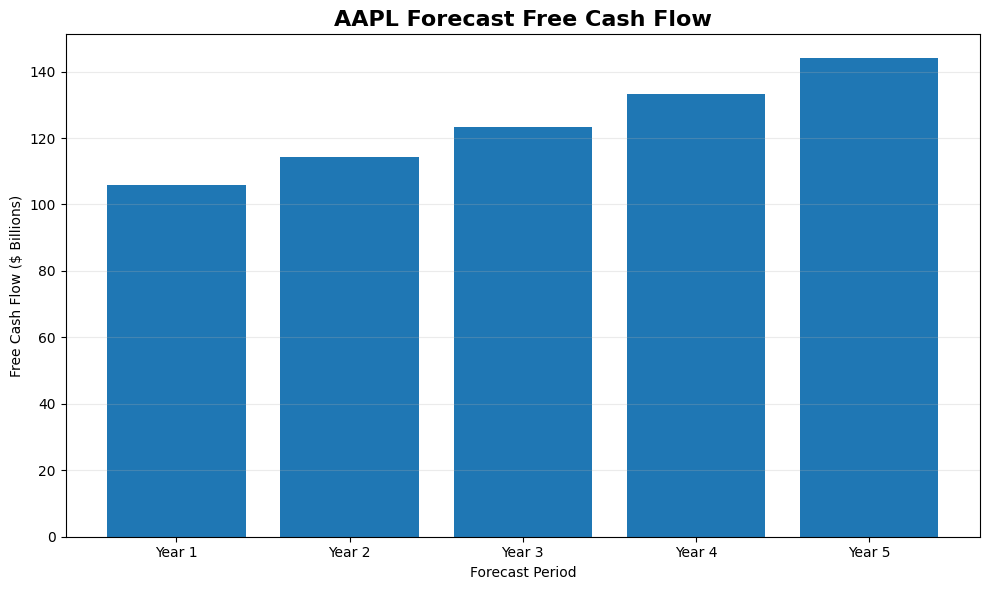

In [26]:
# ============================================================
# FORECAST FREE CASH FLOW VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    forecast_df.index,
    forecast_df["FCF"] / 1e9
)

plt.title(
    f"{TICKER} Forecast Free Cash Flow",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Forecast Period")
plt.ylabel("Free Cash Flow ($ Billions)")

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# MARKET DATA FOR WACC
# ============================================================

stock = data["stock"]

try:
    info = stock.info

    market_cap = info.get("marketCap")
    beta = info.get("beta")

    if market_cap is None:
        raise ValueError("Market capitalization unavailable.")

    if beta is None:
        raise ValueError("Beta unavailable.")

except Exception as e:
    raise RuntimeError(
        f"Unable to retrieve market data: {e}"
    )

print(f"Market Capitalization: ${market_cap / 1e9:.2f} billion")
print(f"Beta: {beta:.2f}")

Market Capitalization: $4789.96 billion
Beta: 1.09


In [28]:
# ============================================================
# TOTAL DEBT
# ============================================================

total_debt_series = find_line_item(
    balance_sheet,
    [
        "Total Debt",
        "Long Term Debt And Capital Lease Obligation",
        "Long Term Debt"
    ]
)

if total_debt_series is None:
    raise ValueError("Total debt could not be found.")

total_debt = abs(
    total_debt_series.dropna().iloc[-1]
)

print(
    f"Total Debt: ${total_debt / 1e9:.2f} billion"
)

Total Debt: $132.48 billion


In [29]:
# ============================================================
# COST OF EQUITY — CAPM
# ============================================================

cost_of_equity = (
    RISK_FREE_RATE
    + beta * EQUITY_RISK_PREMIUM
)

print(
    f"Risk-Free Rate: {RISK_FREE_RATE:.2%}"
)

print(
    f"Beta: {beta:.2f}"
)

print(
    f"Equity Risk Premium: {EQUITY_RISK_PREMIUM:.2%}"
)

print(
    f"Cost of Equity: {cost_of_equity:.2%}"
)

Risk-Free Rate: 4.30%
Beta: 1.09
Equity Risk Premium: 5.50%
Cost of Equity: 10.27%


In [30]:
# ============================================================
# WACC CALCULATION
# ============================================================

cost_of_debt = COST_OF_DEBT

total_capital = (
    market_cap +
    total_debt
)

equity_weight = (
    market_cap /
    total_capital
)

debt_weight = (
    total_debt /
    total_capital
)

after_tax_cost_of_debt = (
    cost_of_debt *
    (1 - TAX_RATE)
)

WACC = (
    equity_weight * cost_of_equity
    +
    debt_weight * after_tax_cost_of_debt
)

print("WACC CALCULATION")
print("-" * 40)

print(
    f"Equity Weight: {equity_weight:.2%}"
)

print(
    f"Debt Weight: {debt_weight:.2%}"
)

print(
    f"Cost of Equity: {cost_of_equity:.2%}"
)

print(
    f"Pre-Tax Cost of Debt: {cost_of_debt:.2%}"
)

print(
    f"After-Tax Cost of Debt: "
    f"{after_tax_cost_of_debt:.2%}"
)

print(
    f"\nWACC: {WACC:.2%}"
)

WACC CALCULATION
----------------------------------------
Equity Weight: 97.31%
Debt Weight: 2.69%
Cost of Equity: 10.27%
Pre-Tax Cost of Debt: 4.50%
After-Tax Cost of Debt: 3.55%

WACC: 10.09%


In [31]:
# ============================================================
# WACC SUMMARY
# ============================================================

wacc_summary = pd.DataFrame({
    "Component": [
        "Risk-Free Rate",
        "Beta",
        "Equity Risk Premium",
        "Cost of Equity",
        "Pre-Tax Cost of Debt",
        "Tax Rate",
        "After-Tax Cost of Debt",
        "Equity Weight",
        "Debt Weight",
        "WACC"
    ],

    "Value": [
        f"{RISK_FREE_RATE:.2%}",
        f"{beta:.2f}",
        f"{EQUITY_RISK_PREMIUM:.2%}",
        f"{cost_of_equity:.2%}",
        f"{cost_of_debt:.2%}",
        f"{TAX_RATE:.2%}",
        f"{after_tax_cost_of_debt:.2%}",
        f"{equity_weight:.2%}",
        f"{debt_weight:.2%}",
        f"{WACC:.2%}"
    ]
})

display(wacc_summary)

,Component,Value
0,Risk-Free Rate,4.30%
1,Beta,1.09
2,Equity Risk Premium,5.50%
3,Cost of Equity,10.27%
4,Pre-Tax Cost of Debt,4.50%
5,Tax Rate,21.00%
6,After-Tax Cost of Debt,3.55%
7,Equity Weight,97.31%
8,Debt Weight,2.69%
9,WACC,10.09%


In [32]:
# ============================================================
# DISCOUNT FACTORS
# ============================================================

discount_periods = np.arange(
    1,
    FORECAST_YEARS + 1
)

discount_factors = (
    1 /
    (1 + WACC) ** discount_periods
)

discount_factor_df = pd.DataFrame({
    "Year": forecast_years,
    "Period": discount_periods,
    "Discount Factor": discount_factors
})

display(discount_factor_df)

,Year,Period,Discount Factor
0,Year 1,1,0.91
1,Year 2,2,0.83
2,Year 3,3,0.75
3,Year 4,4,0.68
4,Year 5,5,0.62


In [33]:
# ============================================================
# PRESENT VALUE OF FORECAST FCF
# ============================================================

pv_fcf = (
    forecast_fcf.values *
    discount_factors
)

pv_fcf_df = pd.DataFrame({
    "Year": forecast_years,
    "FCF": forecast_fcf.values,
    "Discount Factor": discount_factors,
    "Present Value of FCF": pv_fcf
})

display(pv_fcf_df)

,Year,FCF,Discount Factor,Present Value of FCF
0,Year 1,"105,854,711,960.00",0.91,"96,150,968,633.33"
1,Year 2,"114,323,088,916.80",0.83,"94,323,713,000.42"
2,Year 3,"123,468,936,030.14",0.75,"92,531,182,583.45"
3,Year 4,"133,346,450,912.56",0.68,"90,772,717,463.45"
4,Year 5,"144,014,166,985.56",0.62,"89,047,670,262.61"


In [34]:
# ============================================================
# TOTAL PRESENT VALUE OF EXPLICIT FORECAST PERIOD
# ============================================================

pv_explicit_fcf = pv_fcf.sum()

print(
    f"Present Value of Forecast FCF: "
    f"${pv_explicit_fcf / 1e9:.2f} billion"
)

Present Value of Forecast FCF: $462.83 billion


In [35]:
# ============================================================
# TERMINAL YEAR FREE CASH FLOW
# ============================================================

terminal_fcf = (
    forecast_fcf.iloc[-1]
    * (1 + TERMINAL_GROWTH_RATE)
)

print(
    f"Year 5 FCF: "
    f"${forecast_fcf.iloc[-1] / 1e9:.2f} billion"
)

print(
    f"Terminal Growth Rate: "
    f"{TERMINAL_GROWTH_RATE:.2%}"
)

print(
    f"Terminal Year FCF: "
    f"${terminal_fcf / 1e9:.2f} billion"
)

Year 5 FCF: $144.01 billion
Terminal Growth Rate: 2.50%
Terminal Year FCF: $147.61 billion


In [36]:
# ============================================================
# TERMINAL VALUE — GORDON GROWTH MODEL
# ============================================================

if WACC <= TERMINAL_GROWTH_RATE:
    raise ValueError("WACC must be greater than terminal growth rate.")

terminal_value = (
    terminal_fcf /
    (WACC - TERMINAL_GROWTH_RATE)
)

print("TERMINAL VALUE")
print("-" * 40)
print(f"Terminal Year FCF: ${terminal_fcf / 1e9:.2f} billion")
print(f"WACC: {WACC:.2%}")
print(f"Terminal Growth Rate: {TERMINAL_GROWTH_RATE:.2%}")
print(f"Terminal Value: ${terminal_value / 1e9:.2f} billion")

TERMINAL VALUE
----------------------------------------
Terminal Year FCF: $147.61 billion
WACC: 10.09%
Terminal Growth Rate: 2.50%
Terminal Value: $1944.29 billion


In [37]:
# ============================================================
# PRESENT VALUE OF TERMINAL VALUE
# ============================================================

terminal_discount_factor = (
    1 / (1 + WACC) ** FORECAST_YEARS
)

pv_terminal_value = (
    terminal_value * terminal_discount_factor
)

print("PRESENT VALUE OF TERMINAL VALUE")
print("-" * 40)
print(f"Terminal Value: ${terminal_value / 1e9:.2f} billion")
print(f"Discount Factor: {terminal_discount_factor:.4f}")
print(f"PV of Terminal Value: ${pv_terminal_value / 1e9:.2f} billion")

PRESENT VALUE OF TERMINAL VALUE
----------------------------------------
Terminal Value: $1944.29 billion
Discount Factor: 0.6183
PV of Terminal Value: $1202.21 billion


In [38]:
# ============================================================
# ENTERPRISE VALUE
# ============================================================

enterprise_value = (
    pv_explicit_fcf +
    pv_terminal_value
)

print("ENTERPRISE VALUE")
print("-" * 40)
print(f"PV of Explicit FCF: ${pv_explicit_fcf / 1e9:.2f} billion")
print(f"PV of Terminal Value: ${pv_terminal_value / 1e9:.2f} billion")
print(f"\nEnterprise Value: ${enterprise_value / 1e9:.2f} billion")

ENTERPRISE VALUE
----------------------------------------
PV of Explicit FCF: $462.83 billion
PV of Terminal Value: $1202.21 billion

Enterprise Value: $1665.03 billion


In [39]:
# ============================================================
# CASH AND CASH EQUIVALENTS
# ============================================================

cash_series = find_line_item(
    balance_sheet,
    [
        "Cash Cash Equivalents And Short Term Investments",
        "Cash And Cash Equivalents",
        "Cash Financial"
    ]
)

if cash_series is None:
    raise ValueError("Cash data could not be found.")

cash = abs(
    cash_series.dropna().sort_index().iloc[-1]
)

print(f"Cash & Cash Equivalents: ${cash / 1e9:.2f} billion")

Cash & Cash Equivalents: $54.70 billion


In [40]:
# ============================================================
# LATEST TOTAL DEBT
# ============================================================

total_debt_series = find_line_item(
    balance_sheet,
    [
        "Total Debt",
        "Long Term Debt And Capital Lease Obligation",
        "Long Term Debt"
    ]
)

if total_debt_series is None:
    raise ValueError("Total debt could not be found.")

total_debt = abs(
    total_debt_series.dropna().sort_index().iloc[-1]
)

print(f"Total Debt: ${total_debt / 1e9:.2f} billion")

Total Debt: $98.66 billion


In [41]:
# ============================================================
# ENTERPRISE VALUE TO EQUITY VALUE BRIDGE
# ============================================================

net_debt = total_debt - cash

equity_value = (
    enterprise_value
    - total_debt
    + cash
)

print("EQUITY VALUE BRIDGE")
print("-" * 40)
print(f"Enterprise Value: ${enterprise_value / 1e9:.2f} billion")
print(f"Less: Total Debt: ${total_debt / 1e9:.2f} billion")
print(f"Add: Cash: ${cash / 1e9:.2f} billion")
print(f"Net Debt: ${net_debt / 1e9:.2f} billion")
print(f"\nEquity Value: ${equity_value / 1e9:.2f} billion")

EQUITY VALUE BRIDGE
----------------------------------------
Enterprise Value: $1665.03 billion
Less: Total Debt: $98.66 billion
Add: Cash: $54.70 billion
Net Debt: $43.96 billion

Equity Value: $1621.07 billion


In [42]:
# ============================================================
# IMPLIED SHARE PRICE
# ============================================================

shares_outstanding = info.get("sharesOutstanding")

if shares_outstanding is None:
    raise ValueError("Shares outstanding data unavailable.")

implied_share_price = (
    equity_value / shares_outstanding
)

current_price = stock.history(period="5d")["Close"].iloc[-1]

upside_downside = (
    implied_share_price / current_price - 1
)

print("DCF VALUATION RESULT")
print("=" * 50)
print(f"Current AAPL Price: ${current_price:.2f}")
print(f"DCF Implied Price: ${implied_share_price:.2f}")
print(f"Upside / Downside: {upside_downside:.2%}")

DCF VALUATION RESULT
Current AAPL Price: $328.21
DCF Implied Price: $111.08
Upside / Downside: -66.16%


In [43]:
# ============================================================
# DCF SENSITIVITY ANALYSIS
# ============================================================

wacc_range = np.array([
    WACC - 0.02,
    WACC - 0.01,
    WACC,
    WACC + 0.01,
    WACC + 0.02
])

growth_range = np.array([
    TERMINAL_GROWTH_RATE - 0.01,
    TERMINAL_GROWTH_RATE - 0.005,
    TERMINAL_GROWTH_RATE,
    TERMINAL_GROWTH_RATE + 0.005,
    TERMINAL_GROWTH_RATE + 0.01
])

print("WACC Range:")
print([f"{x:.2%}" for x in wacc_range])

print("\nTerminal Growth Range:")
print([f"{x:.2%}" for x in growth_range])

WACC Range:
['8.09%', '9.09%', '10.09%', '11.09%', '12.09%']

Terminal Growth Range:
['1.50%', '2.00%', '2.50%', '3.00%', '3.50%']


In [44]:
# ============================================================
# WACC vs TERMINAL GROWTH SENSITIVITY
# ============================================================

sensitivity = pd.DataFrame(
    index=[f"{w:.2%}" for w in wacc_range],
    columns=[f"{g:.2%}" for g in growth_range],
    dtype=float
)

for wacc in wacc_range:
    for growth in growth_range:

        if wacc <= growth:
            sensitivity.loc[f"{wacc:.2%}", f"{growth:.2%}"] = np.nan
            continue

        # Discount explicit forecast FCFs
        discount_factors = 1 / (1 + wacc) ** discount_periods
        pv_forecast = np.sum(
            forecast_fcf.values * discount_factors
        )

        # Terminal value
        terminal_value_sensitivity = (
            forecast_fcf.iloc[-1] * (1 + growth)
            / (wacc - growth)
        )

        # Discount terminal value
        pv_terminal = (
            terminal_value_sensitivity
            / (1 + wacc) ** FORECAST_YEARS
        )

        # Enterprise value
        ev = pv_forecast + pv_terminal

        # Convert EV to equity value
        equity = (
            ev
            - total_debt
            + cash
        )

        # Convert equity value to share price
        price = equity / shares_outstanding

        sensitivity.loc[
            f"{wacc:.2%}",
            f"{growth:.2%}"
        ] = price

print("DCF IMPLIED SHARE PRICE SENSITIVITY")
print("Rows = WACC | Columns = Terminal Growth")

display(sensitivity)

DCF IMPLIED SHARE PRICE SENSITIVITY
Rows = WACC | Columns = Terminal Growth


,1.50%,2.00%,2.50%,3.00%,3.50%
8.09%,133.45,142.45,153.05,165.75,181.20
9.09%,114.95,121.42,128.87,137.55,147.77
10.09%,100.78,105.61,111.08,117.31,124.50
11.09%,89.58,93.29,97.44,102.10,107.37
12.09%,80.50,83.42,86.65,90.23,94.24


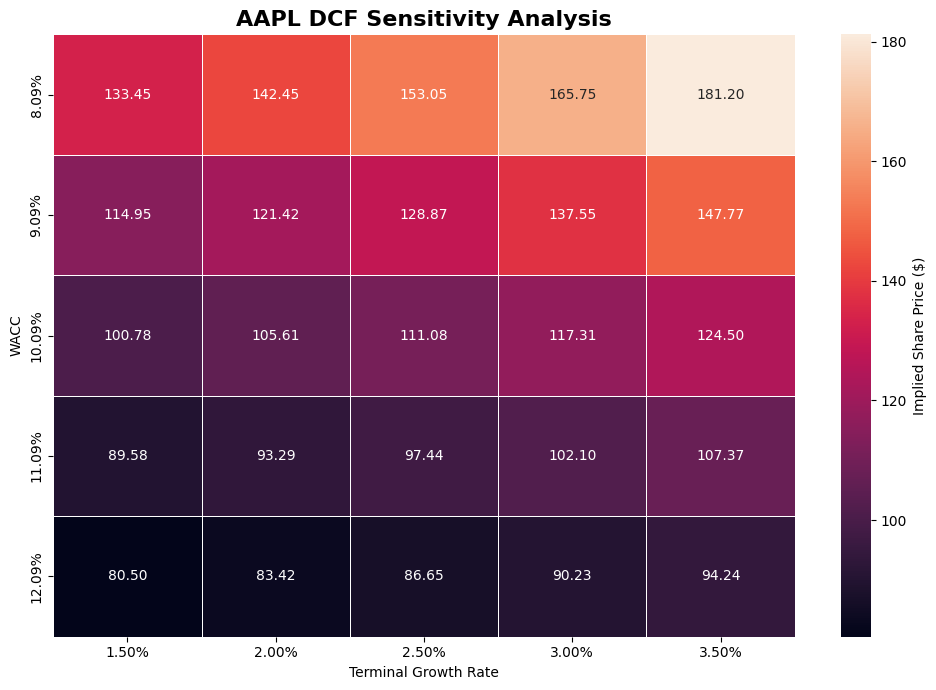

In [45]:
# ============================================================
# SENSITIVITY HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    sensitivity,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Implied Share Price ($)"}
)

plt.title(
    f"{TICKER} DCF Sensitivity Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Terminal Growth Rate")
plt.ylabel("WACC")

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# BULL / BASE / BEAR SCENARIO ANALYSIS
# ============================================================

scenarios = {
    "Bear": {
        "Revenue Growth": 0.04,
        "EBIT Margin": 0.27,
        "WACC": WACC + 0.01,
        "Terminal Growth": 0.020
    },
    "Base": {
        "Revenue Growth": REVENUE_GROWTH_RATE,
        "EBIT Margin": EBIT_MARGIN,
        "WACC": WACC,
        "Terminal Growth": TERMINAL_GROWTH_RATE
    },
    "Bull": {
        "Revenue Growth": 0.11,
        "EBIT Margin": 0.32,
        "WACC": WACC - 0.01,
        "Terminal Growth": 0.030
    }
}

scenario_assumptions = pd.DataFrame(scenarios).T

display(scenario_assumptions.style.format({
    "Revenue Growth": "{:.1%}",
    "EBIT Margin": "{:.1%}",
    "WACC": "{:.1%}",
    "Terminal Growth": "{:.1%}"
}))

,Revenue Growth,EBIT Margin,WACC,Terminal Growth
Bear,4.0%,27.0%,11.1%,2.0%
Base,8.0%,30.0%,10.1%,2.5%
Bull,11.0%,32.0%,9.1%,3.0%


In [47]:
# ============================================================
# SCENARIO VALUATIONS
# ============================================================

scenario_results = {}

for scenario, assumptions in scenarios.items():

    growth = assumptions["Revenue Growth"]
    margin = assumptions["EBIT Margin"]
    wacc = assumptions["WACC"]
    terminal_growth = assumptions["Terminal Growth"]

    # Forecast revenue
    revenues = []
    previous_revenue = latest_revenue

    for _ in range(FORECAST_YEARS):
        next_revenue = previous_revenue * (1 + growth)
        revenues.append(next_revenue)
        previous_revenue = next_revenue

    revenues = np.array(revenues)

    # Forecast operating profit
    ebit_values = revenues * margin

    # NOPAT
    nopat_values = ebit_values * (1 - TAX_RATE)

    # D&A
    da_values = revenues * DA_PERCENT_REVENUE

    # CapEx
    capex_values = revenues * CAPEX_PERCENT_REVENUE

    # Change in NWC
    nwc_values = revenues * NWC_PERCENT_REVENUE
    previous_nwc = latest_revenue * NWC_PERCENT_REVENUE

    changes_nwc = []

    for nwc_value in nwc_values:
        changes_nwc.append(nwc_value - previous_nwc)
        previous_nwc = nwc_value

    changes_nwc = np.array(changes_nwc)

    # Free Cash Flow
    fcfs = (
        nopat_values
        + da_values
        - capex_values
        - changes_nwc
    )

    # Discount forecast FCF
    periods = np.arange(1, FORECAST_YEARS + 1)

    discount_factors = (
        1 / (1 + wacc) ** periods
    )

    pv_forecast = np.sum(
        fcfs * discount_factors
    )

    # Terminal value
    terminal_fcf_scenario = (
        fcfs[-1] * (1 + terminal_growth)
    )

    terminal_value_scenario = (
        terminal_fcf_scenario /
        (wacc - terminal_growth)
    )

    pv_terminal = (
        terminal_value_scenario /
        (1 + wacc) ** FORECAST_YEARS
    )

    # Enterprise value
    ev = pv_forecast + pv_terminal

    # Equity value
    equity = ev - total_debt + cash

    # Implied price
    price = equity / shares_outstanding

    scenario_results[scenario] = {
        "Enterprise Value": ev,
        "Equity Value": equity,
        "Implied Share Price": price
    }

scenario_results_df = pd.DataFrame(scenario_results).T

display(
    scenario_results_df.style.format({
        "Enterprise Value": "${:,.2f}",
        "Equity Value": "${:,.2f}",
        "Implied Share Price": "${:,.2f}"
    })
)

,Enterprise Value,Equity Value,Implied Share Price
Bear,"$1,077,860,511,919.83","$1,033,900,511,919.83",$70.84
Base,"$1,665,032,742,244.24","$1,621,072,742,244.24",$111.08
Bull,"$2,474,485,084,480.22","$2,430,525,084,480.22",$166.54


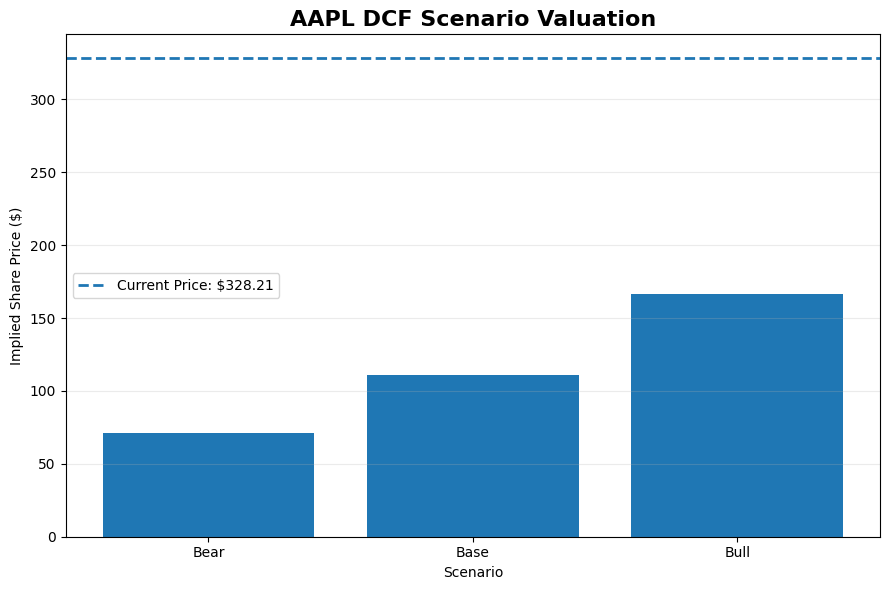

In [48]:
# ============================================================
# SCENARIO IMPLIED SHARE PRICE
# ============================================================

scenario_prices = scenario_results_df[
    "Implied Share Price"
]

plt.figure(figsize=(9, 6))

plt.bar(
    scenario_prices.index,
    scenario_prices.values
)

plt.axhline(
    current_price,
    linestyle="--",
    linewidth=2,
    label=f"Current Price: ${current_price:.2f}"
)

plt.title(
    f"{TICKER} DCF Scenario Valuation",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Implied Share Price ($)")
plt.xlabel("Scenario")
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# FINAL DCF VALUATION SUMMARY
# ============================================================

valuation_summary = pd.DataFrame({
    "Metric": [
        "Current Share Price",
        "DCF Implied Share Price",
        "Upside / Downside",
        "Enterprise Value",
        "Equity Value",
        "PV of Explicit FCF",
        "PV of Terminal Value",
        "Terminal Value % of EV"
    ],
    "Value": [
        current_price,
        implied_share_price,
        upside_downside,
        enterprise_value,
        equity_value,
        pv_explicit_fcf,
        pv_terminal_value,
        pv_terminal_value / enterprise_value
    ]
})

display(
    valuation_summary.style.format({
        "Value": lambda x: (
            f"{x:.2%}" if abs(x) < 1
            else f"${x:,.2f}"
        )
    })
)

,Metric,Value
0,Current Share Price,$328.21
1,DCF Implied Share Price,$111.08
2,Upside / Downside,-66.16%
3,Enterprise Value,"$1,665,032,742,244.24"
4,Equity Value,"$1,621,072,742,244.24"
5,PV of Explicit FCF,"$462,826,251,943.26"
6,PV of Terminal Value,"$1,202,206,490,300.98"
7,Terminal Value % of EV,72.20%


In [50]:
# ============================================================
# KEY DCF METRICS
# ============================================================

terminal_value_percentage = (
    pv_terminal_value / enterprise_value
)

print("=" * 55)
print(f"{TICKER} DCF VALUATION")
print("=" * 55)

print(f"Current Price       : ${current_price:.2f}")
print(f"DCF Value / Share   : ${implied_share_price:.2f}")
print(f"Upside / Downside   : {upside_downside:.2%}")
print(f"Enterprise Value    : ${enterprise_value / 1e9:.2f}B")
print(f"Equity Value        : ${equity_value / 1e9:.2f}B")
print(f"WACC                : {WACC:.2%}")
print(f"Terminal Growth     : {TERMINAL_GROWTH_RATE:.2%}")
print(f"Terminal Value / EV : {terminal_value_percentage:.2%}")
print("=" * 55)

AAPL DCF VALUATION
Current Price       : $328.21
DCF Value / Share   : $111.08
Upside / Downside   : -66.16%
Enterprise Value    : $1665.03B
Equity Value        : $1621.07B
WACC                : 10.09%
Terminal Growth     : 2.50%
Terminal Value / EV : 72.20%


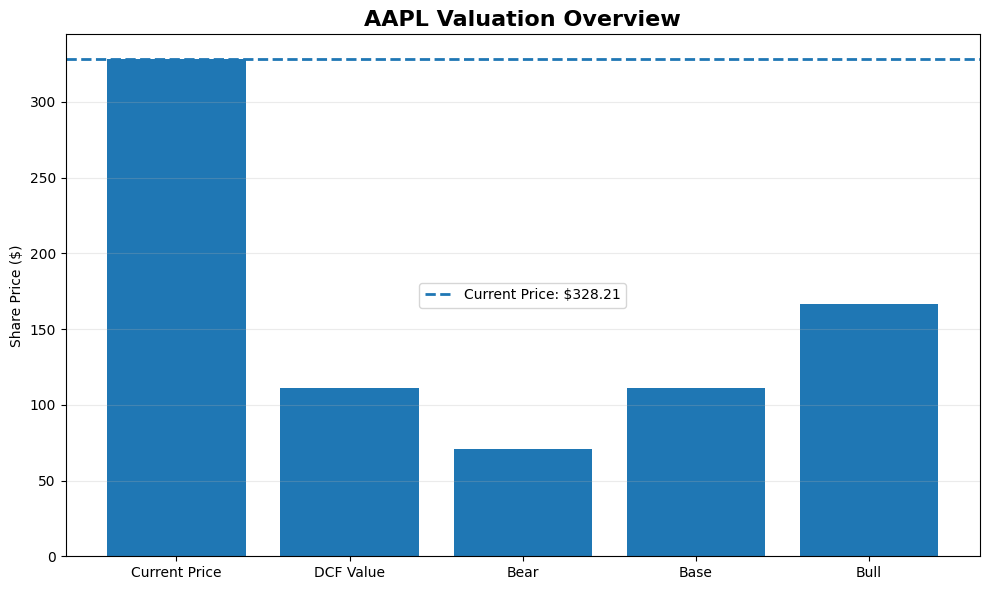

In [51]:
# ============================================================
# CURRENT PRICE VS DCF VALUATION
# ============================================================

plt.figure(figsize=(10, 6))

labels = [
    "Current Price",
    "DCF Value",
    "Bear",
    "Base",
    "Bull"
]

values = [
    current_price,
    implied_share_price,
    scenario_results_df.loc["Bear", "Implied Share Price"],
    scenario_results_df.loc["Base", "Implied Share Price"],
    scenario_results_df.loc["Bull", "Implied Share Price"]
]

plt.bar(labels, values)

plt.axhline(
    current_price,
    linestyle="--",
    linewidth=2,
    label=f"Current Price: ${current_price:.2f}"
)

plt.title(
    f"{TICKER} Valuation Overview",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Share Price ($)")
plt.grid(axis="y", alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# INVESTMENT CONCLUSION
# ============================================================

if upside_downside >= 0.15:
    valuation_view = "UNDERVALUED"
elif upside_downside <= -0.15:
    valuation_view = "OVERVALUED"
else:
    valuation_view = "FAIRLY VALUED"

print("=" * 65)
print(f"{TICKER} DCF INVESTMENT CONCLUSION")
print("=" * 65)

print(f"\nCurrent Market Price : ${current_price:.2f}")
print(f"DCF Implied Value    : ${implied_share_price:.2f}")
print(f"Upside / Downside    : {upside_downside:.2%}")
print(f"Valuation View       : {valuation_view}")

print("\nScenario Range")
print("-" * 40)
print(
    f"Bear Case : "
    f"${scenario_results_df.loc['Bear', 'Implied Share Price']:.2f}"
)
print(
    f"Base Case : "
    f"${scenario_results_df.loc['Base', 'Implied Share Price']:.2f}"
)
print(
    f"Bull Case : "
    f"${scenario_results_df.loc['Bull', 'Implied Share Price']:.2f}"
)

print("\nKey Interpretation")
print("-" * 40)

if valuation_view == "OVERVALUED":
    print(
        "The DCF model indicates that the current market price "
        "is above the estimated intrinsic value under the "
        "selected assumptions."
    )
elif valuation_view == "UNDERVALUED":
    print(
        "The DCF model indicates that the current market price "
        "is below the estimated intrinsic value under the "
        "selected assumptions."
    )
else:
    print(
        "The DCF model indicates that the current market price "
        "is reasonably close to estimated intrinsic value."
    )

print(
    "\nNote: DCF valuation is highly sensitive to assumptions "
    "such as WACC, growth, margins and terminal growth."
)

AAPL DCF INVESTMENT CONCLUSION

Current Market Price : $328.21
DCF Implied Value    : $111.08
Upside / Downside    : -66.16%
Valuation View       : OVERVALUED

Scenario Range
----------------------------------------
Bear Case : $70.84
Base Case : $111.08
Bull Case : $166.54

Key Interpretation
----------------------------------------
The DCF model indicates that the current market price is above the estimated intrinsic value under the selected assumptions.

Note: DCF valuation is highly sensitive to assumptions such as WACC, growth, margins and terminal growth.


In [53]:
# ============================================================
# KEY MODEL ASSUMPTIONS
# ============================================================

key_assumptions = pd.DataFrame({
    "Assumption": [
        "Forecast Period",
        "Revenue Growth",
        "EBIT Margin",
        "D&A % Revenue",
        "CapEx % Revenue",
        "NWC % Revenue",
        "Tax Rate",
        "Risk-Free Rate",
        "Equity Risk Premium",
        "Cost of Debt",
        "WACC",
        "Terminal Growth"
    ],
    "Value": [
        f"{FORECAST_YEARS} years",
        f"{REVENUE_GROWTH_RATE:.2%}",
        f"{EBIT_MARGIN:.2%}",
        f"{DA_PERCENT_REVENUE:.2%}",
        f"{CAPEX_PERCENT_REVENUE:.2%}",
        f"{NWC_PERCENT_REVENUE:.2%}",
        f"{TAX_RATE:.2%}",
        f"{RISK_FREE_RATE:.2%}",
        f"{EQUITY_RISK_PREMIUM:.2%}",
        f"{COST_OF_DEBT:.2%}",
        f"{WACC:.2%}",
        f"{TERMINAL_GROWTH_RATE:.2%}"
    ]
})

display(key_assumptions)

,Assumption,Value
0,Forecast Period,5 years
1,Revenue Growth,8.00%
2,EBIT Margin,30.00%
3,D&A % Revenue,4.00%
4,CapEx % Revenue,4.00%
5,NWC % Revenue,2.00%
6,Tax Rate,21.00%
7,Risk-Free Rate,4.30%
8,Equity Risk Premium,5.50%
9,Cost of Debt,4.50%


In [54]:
# ============================================================
# MODEL LIMITATIONS
# ============================================================

limitations = [
    "Forecast assumptions are simplified and should be refined with company-specific research.",
    "DCF valuation is highly sensitive to WACC and terminal growth assumptions.",
    "The model uses a normalized tax rate rather than forecasting effective tax rates.",
    "Working capital is estimated as a percentage of revenue.",
    "The model does not separately forecast individual operating expense lines.",
    "Scenario outputs should be interpreted as valuation ranges rather than precise price targets."
]

print("MODEL LIMITATIONS")
print("=" * 65)

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

MODEL LIMITATIONS
1. Forecast assumptions are simplified and should be refined with company-specific research.
2. DCF valuation is highly sensitive to WACC and terminal growth assumptions.
3. The model uses a normalized tax rate rather than forecasting effective tax rates.
4. Working capital is estimated as a percentage of revenue.
5. The model does not separately forecast individual operating expense lines.
6. Scenario outputs should be interpreted as valuation ranges rather than precise price targets.


# Automated DCF Valuation Engine — AAPL

## Project Overview

This project builds a Python-based Discounted Cash Flow (DCF) valuation model to estimate the intrinsic value of Apple Inc. (AAPL).

The model:
- Retrieves historical financial statements using `yfinance`
- Analyzes revenue, EBIT, D&A, CapEx and working capital
- Forecasts 5 years of Free Cash Flow to the Firm (FCFF)
- Calculates WACC using CAPM
- Estimates terminal value using the Gordon Growth Model
- Calculates Enterprise Value and Equity Value
- Produces an implied share price
- Performs WACC vs. terminal growth sensitivity analysis
- Evaluates Bear, Base and Bull scenarios
- Visualizes the valuation results using Python

### Valuation Framework

**Revenue → EBIT → NOPAT → FCFF → Discount at WACC → Enterprise Value → Equity Value → Implied Share Price**

# Key Results

| Metric | Result |
|---|---:|
| Current Share Price | ~$328 |
| Base DCF Value | ~$111 |
| Bear Case | ~$71 |
| Bull Case | ~$167 |
| Enterprise Value | ~$1.67T |
| PV of Explicit FCF | ~$462.83B |
| PV of Terminal Value | ~$1.20T |

## Interpretation

Under the selected assumptions, the DCF model estimates an intrinsic value substantially below the current market price.

This suggests that the market price embeds stronger expectations for future growth, profitability and/or terminal value than those assumed in the base-case model.

The sensitivity analysis demonstrates that the valuation is highly dependent on WACC and terminal growth assumptions. Therefore, the model should be interpreted as a valuation framework and range rather than a precise price target.

# Technical Skills Demonstrated

### Finance
- Discounted Cash Flow (DCF) Valuation
- Free Cash Flow to the Firm (FCFF)
- WACC & CAPM
- Terminal Value
- Enterprise Value → Equity Value Bridge
- Scenario Analysis
- Sensitivity Analysis

### Python
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- yfinance
- Financial Data Analysis
- Data Visualization
- Automated Financial Modeling

### Key Concepts

**FCFF = NOPAT + D&A − CapEx − Change in NWC**

**Terminal Value = Terminal Year FCFF / (WACC − Terminal Growth)**

**Enterprise Value = PV of Explicit FCFF + PV of Terminal Value**

**Equity Value = Enterprise Value − Debt + Cash**